In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [6]:
from sklearn.datasets import make_regression
x,y=make_regression(n_samples=1000,n_features=2,n_targets=1,noise=3)

In [7]:
pd.DataFrame(x)

,0,1
0,-0.737356,0.389114
1,-1.240028,-0.694530
2,-1.552864,-0.730814
3,-0.989700,0.237912
4,-1.324267,0.750824
...,...,...
995,0.088027,1.685039
996,-2.334176,0.703025
997,-0.787444,-1.445705
998,-0.555931,-0.477984


In [8]:
pd.DataFrame(y)

,0
0,-34.969961
1,-66.492209
2,-83.427519
3,-52.003380
4,-67.399059
...,...
995,11.523331
996,-116.900676
997,-50.383528
998,-33.607950


In [9]:
x

array([[-0.73735622,  0.3891144 ],
       [-1.24002811, -0.69452968],
       [-1.55286413, -0.73081351],
       ...,
       [-0.78744399, -1.44570471],
       [-0.55593107, -0.47798413],
       [ 0.23057378, -0.9153598 ]])

In [10]:
y

array([-3.49699614e+01, -6.64922087e+01, -8.34275185e+01, -5.20033802e+01,
       -6.73990589e+01, -1.65271463e+01, -6.87658387e+01,  5.37667015e+01,
        6.77628942e+01,  9.10008394e+01, -5.38853041e+00,  7.26253473e+00,
       -5.80362406e-01, -4.19207755e+00,  7.64654872e+01, -6.19843446e+01,
        1.41739217e+01,  5.16800913e+01, -4.96795936e+01,  1.06343122e+02,
        2.51438169e+01,  1.72439480e+01, -9.06176457e+00, -1.31335297e+02,
        1.11989533e+02, -3.55144083e+01, -8.59794449e-01, -1.84144766e+01,
       -4.17947072e+01, -3.38111538e+01, -3.04319511e+00,  2.83233955e+01,
       -4.64691517e+00, -2.62709135e+01,  1.63843974e+01, -1.04056529e+02,
        6.65423728e+00, -2.79632258e+01, -1.39681955e+01,  3.01495904e+01,
       -1.71395513e+01, -5.10574815e+01,  4.54745376e+01,  2.83994807e+01,
        7.20722123e+01, -2.26005819e+01, -5.26991000e+01,  8.22494514e+00,
        6.27085972e+01,  1.07112857e+01, -4.59150860e+01, -7.96389975e+00,
        4.34156342e+01,  

<Axes: xlabel='0', ylabel='1'>

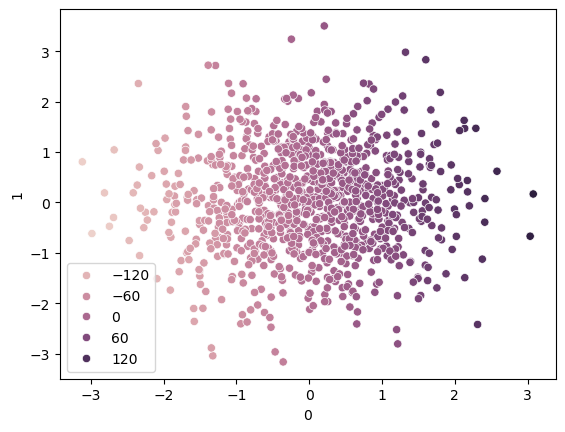

In [13]:
sns.scatterplot(x=pd.DataFrame(x)[0],y=pd.DataFrame(x)[1],hue=y)

In [14]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.30,random_state=1)

In [15]:
x_train.shape,x_test.shape

((700, 2), (300, 2))

In [16]:
from sklearn.svm import SVR
svr=SVR(kernel='linear')

In [17]:
svr

SVR(kernel='linear')

In [18]:
svr.fit(x_train,y_train)

SVR(kernel='linear')

In [19]:
svr.coef_

array([[52.32913205,  6.32696944]])

In [20]:
y_pred=svr.predict(x_test)

In [21]:
y_pred

array([  40.12791697,   42.4414628 ,  -13.81296263,  -16.82685292,
         -0.46565493,  -15.53470924,    6.52886967,    6.49096221,
         18.46494106,   11.22556583,   -5.45560093,  -50.02187632,
        -33.2453965 ,  -67.1244299 ,  -66.37501464,    5.51692074,
        -81.95584124,  -66.36027338,  -17.93785602,  -56.49187921,
         14.08826802,   36.60481457, -112.92892831,   20.50362658,
          4.43316283,   -7.05803021,   23.87965184,  -23.17816439,
        -11.36745456,   36.63734592,  -53.68091114,   -4.70133357,
         62.76449938,   53.27292961,   25.44864126,  -51.16919537,
          0.75521734,   30.73019067,   23.52010531,  103.46935969,
        -64.93432667,  -22.26017718,   58.17884731,  114.5558685 ,
         31.21866364,  -15.95073025,    5.81159445,  -51.85186904,
          7.3379936 ,   15.19265278,   11.89634476,   16.420434  ,
          9.89530246, -103.90775622,   42.43530801,  -35.60594893,
        -43.92514623,  -58.7407673 ,  -86.07778636,  -56.04527

In [23]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.9966997445772572

In [28]:
# HyperParameter tunning with SVR
from sklearn.model_selection import GridSearchCV
params={'C':[0.1,0.2,1,2,3,10,50,100],
       'gamma':[1,0.1,0.2,0.001,0.003],
       'kernel':['linear'],
       'epsilon':[0.01,0.1,0.2,0.3]}
grid=GridSearchCV(SVR(),param_grid=params,cv=5,verbose=3)
grid

GridSearchCV(cv=5, estimator=SVR(),
             param_grid={'C': [0.1, 0.2, 1, 2, 3, 10, 50, 100],
                         'epsilon': [0.01, 0.1, 0.2, 0.3],
                         'gamma': [1, 0.1, 0.2, 0.001, 0.003],
                         'kernel': ['linear']},
             verbose=3)

In [29]:
grid.fit(x_train,y_train)

Fitting 5 folds for each of 160 candidates, totalling 800 fits
[CV 1/5] END C=0.1, epsilon=0.01, gamma=1, kernel=linear;, score=0.955 total time=   0.0s
[CV 2/5] END C=0.1, epsilon=0.01, gamma=1, kernel=linear;, score=0.960 total time=   0.0s
[CV 3/5] END C=0.1, epsilon=0.01, gamma=1, kernel=linear;, score=0.958 total time=   0.0s
[CV 4/5] END C=0.1, epsilon=0.01, gamma=1, kernel=linear;, score=0.956 total time=   0.0s
[CV 5/5] END C=0.1, epsilon=0.01, gamma=1, kernel=linear;, score=0.959 total time=   0.0s
[CV 1/5] END C=0.1, epsilon=0.01, gamma=0.1, kernel=linear;, score=0.955 total time=   0.0s
[CV 2/5] END C=0.1, epsilon=0.01, gamma=0.1, kernel=linear;, score=0.960 total time=   0.0s
[CV 3/5] END C=0.1, epsilon=0.01, gamma=0.1, kernel=linear;, score=0.958 total time=   0.0s
[CV 4/5] END C=0.1, epsilon=0.01, gamma=0.1, kernel=linear;, score=0.956 total time=   0.0s
[CV 5/5] END C=0.1, epsilon=0.01, gamma=0.1, kernel=linear;, score=0.959 total time=   0.0s
[CV 1/5] END C=0.1, epsilon

GridSearchCV(cv=5, estimator=SVR(),
             param_grid={'C': [0.1, 0.2, 1, 2, 3, 10, 50, 100],
                         'epsilon': [0.01, 0.1, 0.2, 0.3],
                         'gamma': [1, 0.1, 0.2, 0.001, 0.003],
                         'kernel': ['linear']},
             verbose=3)

In [30]:
grid.best_params_

{'C': 50, 'epsilon': 0.1, 'gamma': 1, 'kernel': 'linear'}

In [32]:
grid.best_score_

0.9966826541749292

In [34]:
final_model=grid.best_estimator_

In [35]:
y_pred=final_model.predict(x_test)

In [36]:
y_pred

array([  40.27333836,   42.60091879,  -13.90385411,  -16.93263289,
         -0.49824338,  -15.63236996,    6.52299805,    6.48733844,
         18.51541299,   11.24353429,   -5.50995999,  -50.27533813,
        -33.42923391,  -67.45506298,  -66.7001574 ,    5.51050251,
        -82.35770772,  -66.68736137,  -18.0462749 ,  -56.77498699,
         14.11892514,   36.73672686, -113.46454276,   20.56168135,
          4.41702438,   -7.11502677,   23.95599296,  -23.31169058,
        -11.44937563,   36.77360526,  -53.95321282,   -4.76094666,
         63.01325218,   53.48155142,   25.53008784,  -51.43069535,
          0.73544683,   30.83760985,   23.59071776,  103.9024432 ,
        -65.25184181,  -22.39234208,   58.41201812,  115.03834473,
         31.32642618,  -16.0586896 ,    5.80816428,  -52.11456123,
          7.33861812,   15.22351903,   11.91668156,   16.46709742,
          9.90686662, -104.40105175,   42.59322236,  -35.80043119,
        -44.15443838,  -59.03788019,  -86.49450188,  -56.32555